# Peak-Aware Global GRU — Container Comparison (Optional Analysis)

**Purpose:** Interactive visualization and analysis for the completed Peak-Aware Global GRU study.

This notebook is **not** part of the experimental pipeline. It performs **read-only** analysis of locked evaluation artifacts for thesis figures, presentation screenshots, and viva demonstrations.

## Official experiment references

| Role | Path |
|------|------|
| **Global baseline (control)** | `experiments/global_gru_baseline_2026-07-17_121748/` |
| **Peak-Aware Global (treatment)** | `experiments/peak_aware_global_validation_vs1_2026-07-17_170939/` |

## Read-only notice

- Does **not** retrain models, regenerate official evaluations, or modify experiment JSON/metadata.
- Uses frozen inference caches and CSV outputs from Stage 3 evaluation.
- Optional figure exports save **only** to `discussion/figures/` under the official treatment experiment directory.


In [1]:
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

REPO_ROOT = Path("..").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from utils.global_config import FORECAST_HORIZON
from utils.hybrid_evaluation import compute_day1_metrics
from utils.peak_detection import load_peak_thresholds
from utils.peak_evaluation import (
    GLOBAL_INFERENCE_CACHE_PRED_KEY,
    compute_peak_subset_metrics_from_global_arrays,
    label_day1_peak_timesteps,
)

# --- Official experiment paths (read-only) ---
BASELINE_DIR = REPO_ROOT / "experiments/global_gru_baseline_2026-07-17_121748"
TREATMENT_DIR = REPO_ROOT / "experiments/peak_aware_global_validation_vs1_2026-07-17_170939"
EVAL_DIR = TREATMENT_DIR / "evaluation"
FIGURES_DIR = TREATMENT_DIR / "discussion/figures"

# --- Plot styling (publication-friendly) ---
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
})

COLOR_ACTUAL = "#2CA02C"
COLOR_BASELINE = "#4C72B0"
COLOR_PEAK_AWARE = "#C44E52"
PEAK_SHADE = "#C44E52"

DAY1_STEPS = FORECAST_HORIZON


def load_inference_cache(path: Path) -> dict[str, dict[str, np.ndarray]]:
    """Load a frozen Day-1 inference cache (read-only)."""
    with open(path, "rb") as handle:
        return pickle.load(handle)


def parse_comparison_table(path: Path) -> pd.DataFrame:
    return pd.read_csv(path)


def save_publication_figure(fig: plt.Figure, stem: str) -> None:
    """Save PNG + PDF under discussion/figures/ (optional exports only)."""
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    for ext in ("png", "pdf"):
        out = FIGURES_DIR / f"{stem}.{ext}"
        fig.savefig(out, bbox_inches="tight")
        print(f"Saved {out.relative_to(REPO_ROOT)}")


Importing plotly failed. Interactive plots will not work.


## 2. Load artifacts


In [2]:
# Evaluation CSVs
per_container_df = pd.read_csv(EVAL_DIR / "per_container_comparison.csv")
peak_per_container_df = pd.read_csv(EVAL_DIR / "peak_subset_per_container_comparison.csv")
comparison_table_df = parse_comparison_table(EVAL_DIR / "comparison_table.csv")
baseline_eval_df = pd.read_csv(EVAL_DIR / "baseline_evaluation_df.csv")
treatment_eval_df = pd.read_csv(EVAL_DIR / "evaluation_df.csv")

# Peak thresholds + inference caches (no model loading)
peak_thresholds = load_peak_thresholds(TREATMENT_DIR / "peak" / "peak_thresholds.pkl")
baseline_cache = load_inference_cache(EVAL_DIR / "baseline_inference_cache.pkl")
treatment_cache = load_inference_cache(EVAL_DIR / "treatment_inference_cache.pkl")

container_ids = sorted(per_container_df["container_id"].tolist())
assert set(baseline_cache) == set(treatment_cache)
assert set(container_ids).issubset(set(baseline_cache))

print(f"Baseline reference : {BASELINE_DIR.relative_to(REPO_ROOT)}")
print(f"Treatment reference: {TREATMENT_DIR.relative_to(REPO_ROOT)}")
print(f"Evaluated containers: {len(container_ids)}")
print(f"Cache containers     : {len(baseline_cache)}")


Baseline reference : experiments/global_gru_baseline_2026-07-17_121748
Treatment reference: experiments/peak_aware_global_validation_vs1_2026-07-17_170939
Evaluated containers: 99
Cache containers     : 99


## 3. Dataset summary


In [3]:
def _metric_from_table(scope: str, metric: str) -> float:
    row = comparison_table_df[
        (comparison_table_df["scope"] == scope) & (comparison_table_df["metric"] == metric)
    ]
    if row.empty:
        return float("nan")
    return float(row.iloc[0]["baseline"]), float(row.iloc[0]["peak_aware_global"]), float(row.iloc[0]["delta_treatment_minus_baseline"])


summary_rows = []
for scope, metrics in [
    ("overall", ["day1_mae", "day1_rmse", "day1_mape"]),
    ("peak_subset", ["peak_mae", "peak_rmse", "non_peak_mae", "non_peak_rmse", "peak_step_fraction"]),
]:
    for metric in metrics:
        baseline, treatment, delta = _metric_from_table(scope, metric)
        summary_rows.append({
            "scope": scope,
            "metric": metric,
            "baseline": baseline,
            "peak_aware_global": treatment,
            "delta_treatment_minus_baseline": delta,
        })

cohort_summary_df = pd.DataFrame(summary_rows)
display(cohort_summary_df.round(4))

per_container_delta = per_container_df["delta_day1_mae"]
print(
    f"Per-container overall: {int((per_container_delta < 0).sum())} improved / "
    f"{int((per_container_delta > 0).sum())} worsened (mean ΔMAE {per_container_delta.mean():+.3f})"
)
peak_delta = per_container_df["delta_peak_mae"].dropna()
print(
    f"Peak MAE improved on {int((peak_delta < 0).sum())} / {len(peak_delta)} containers with ≥1 peak step"
)


,scope,metric,baseline,peak_aware_global,delta_treatment_minus_baseline
0,overall,day1_mae,1.9242,2.1737,0.2495
1,overall,day1_rmse,2.6105,2.7577,0.1472
2,overall,day1_mape,116.5026,163.7714,47.2689
3,peak_subset,peak_mae,3.4257,2.6490,-0.7766
4,peak_subset,peak_rmse,6.5594,5.3164,-1.2430
5,peak_subset,non_peak_mae,1.4062,2.0097,0.6035
6,peak_subset,non_peak_rmse,2.4552,3.5018,1.0466
7,peak_subset,peak_step_fraction,0.2565,0.2565,0.0000


Per-container overall: 23 improved / 76 worsened (mean ΔMAE +0.249)
Peak MAE improved on 89 / 98 containers with ≥1 peak step


## 4. Container selector

Change `SAMPLE_CID` below, or use the dropdown widget (if available) and re-run the comparison cells.


In [5]:
SAMPLE_CID = "c_11461"  # default demonstration container

try:
    import ipywidgets as widgets
    from IPython.display import clear_output

    container_dropdown = widgets.Dropdown(
        options=container_ids,
        value=SAMPLE_CID if SAMPLE_CID in container_ids else container_ids[0],
        description="Container:",
        layout=widgets.Layout(width="320px"),
    )
    display(container_dropdown)

    def get_selected_container() -> str:
        return container_dropdown.value
except ImportError:
    container_dropdown = None

    def get_selected_container() -> str:
        return SAMPLE_CID

print(f"Default / current selection: {get_selected_container()}")


Dropdown(description='Container:', index=19, layout=Layout(width='320px'), options=('c_10032', 'c_10034', 'c_1…

Default / current selection: c_11461


## 5. Interactive comparison


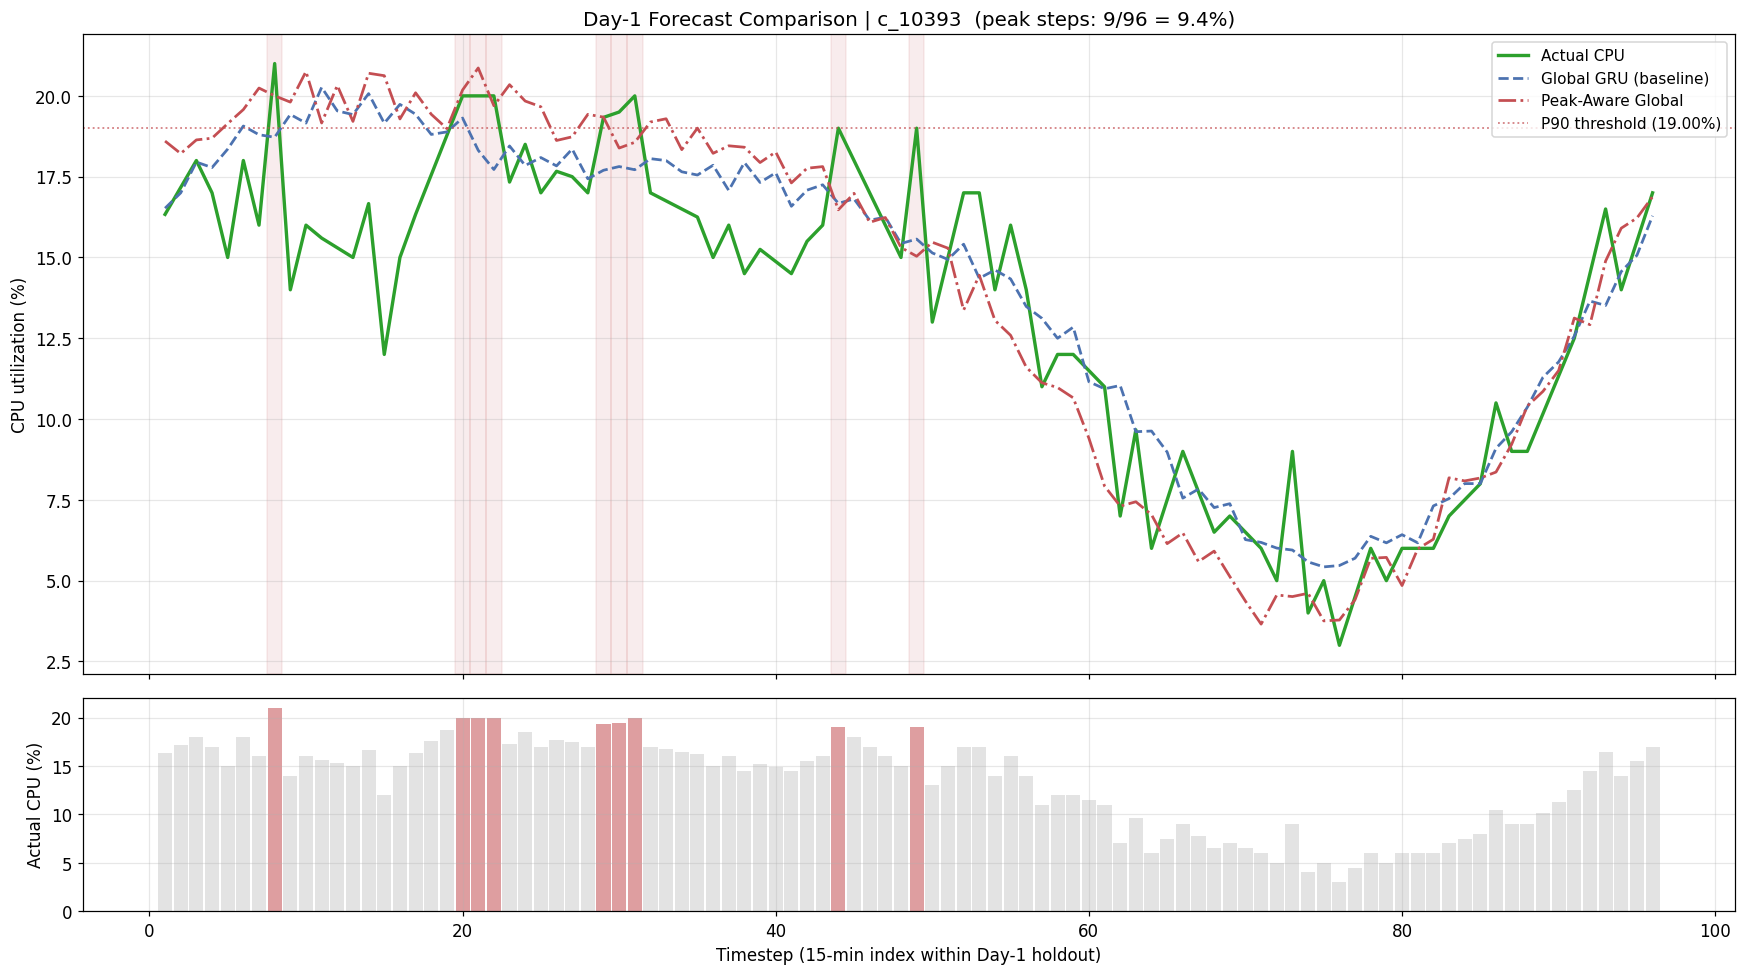

In [28]:
def get_container_arrays(container_id: str) -> tuple[np.ndarray, np.ndarray, np.ndarray, float]:
    if container_id not in baseline_cache:
        raise KeyError(f"{container_id} not in inference caches")
    if container_id not in peak_thresholds:
        raise KeyError(f"{container_id} not in peak thresholds")

    actual = np.ravel(baseline_cache[container_id]["actual_day1_real"])
    baseline_pred = np.ravel(baseline_cache[container_id][GLOBAL_INFERENCE_CACHE_PRED_KEY])
    treatment_pred = np.ravel(treatment_cache[container_id][GLOBAL_INFERENCE_CACHE_PRED_KEY])
    threshold = float(peak_thresholds[container_id])
    return actual, baseline_pred, treatment_pred, threshold


def plot_container_comparison(container_id: str, *, save_stem: str | None = None) -> plt.Figure:
    actual, baseline_pred, treatment_pred, threshold = get_container_arrays(container_id)
    steps = np.arange(1, len(actual) + 1)
    peak_mask = label_day1_peak_timesteps(actual, threshold)

    fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True, gridspec_kw={"height_ratios": [3, 1]})

    ax = axes[0]
    ax.plot(steps, actual, color=COLOR_ACTUAL, linewidth=2.2, label="Actual CPU")
    ax.plot(steps, baseline_pred, color=COLOR_BASELINE, linewidth=1.8, linestyle="--", label="Global GRU (baseline)")
    ax.plot(steps, treatment_pred, color=COLOR_PEAK_AWARE, linewidth=1.8, linestyle="-.", label="Peak-Aware Global")

    for idx in np.where(peak_mask)[0]:
        ax.axvspan(idx + 0.5, idx + 1.5, color=PEAK_SHADE, alpha=0.10)

    ax.axhline(threshold, color=PEAK_SHADE, linestyle=":", linewidth=1.2, alpha=0.7, label=f"P90 threshold ({threshold:.2f}%)")
    ax.set_title(
        f"Day-1 Forecast Comparison | {container_id}  "
        f"(peak steps: {int(peak_mask.sum())}/{len(steps)} = {peak_mask.mean():.1%})"
    )
    ax.set_ylabel("CPU utilization (%)")
    ax.legend(loc="upper right")
    ax.grid(alpha=0.3)

    ax2 = axes[1]
    ax2.bar(steps, actual, color=np.where(peak_mask, PEAK_SHADE, "#CCCCCC"), alpha=0.55, width=0.9, label="Actual (peak highlighted)")
    ax2.set_xlabel("Timestep (15-min index within Day-1 holdout)")
    ax2.set_ylabel("Actual CPU (%)")
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    if save_stem:
        save_publication_figure(fig, save_stem)
    return fig


selected_cid = get_selected_container()
fig_compare = plot_container_comparison(selected_cid)
plt.show()


## 6. Metrics table (selected container)


In [29]:
def container_metrics_table(container_id: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    actual, baseline_pred, treatment_pred, threshold = get_container_arrays(container_id)

    baseline_metrics = compute_peak_subset_metrics_from_global_arrays(
        container_id, actual, baseline_pred, threshold
    )
    treatment_metrics = compute_peak_subset_metrics_from_global_arrays(
        container_id, actual, treatment_pred, threshold
    )

    rows = []
    for label, key_mae, key_rmse in [
        ("Overall", "overall_mae", "overall_rmse"),
        ("Peak subset", "peak_mae", "peak_rmse"),
        ("Non-peak subset", "non_peak_mae", "non_peak_rmse"),
    ]:
        rows.append({
            "subset": label,
            "baseline_mae": baseline_metrics[key_mae],
            "baseline_rmse": baseline_metrics[key_rmse],
            "peak_aware_mae": treatment_metrics[key_mae],
            "peak_aware_rmse": treatment_metrics[key_rmse],
            "delta_mae": treatment_metrics[key_mae] - baseline_metrics[key_mae],
            "delta_rmse": treatment_metrics[key_rmse] - baseline_metrics[key_rmse],
        })

    metrics_table = pd.DataFrame(rows)

    info = pd.DataFrame([
        {"field": "container_id", "value": container_id},
        {"field": "P90 threshold (%)", "value": threshold},
        {"field": "peak step count", "value": int(baseline_metrics["peak_steps"])},
        {"field": "peak fraction", "value": float(baseline_metrics["peak_fraction"])},
    ])

    saved_row = per_container_df.loc[per_container_df["container_id"] == container_id]
    if not saved_row.empty:
        saved_delta_mae = float(saved_row.iloc[0]["delta_day1_mae"])
        recompute_mae = float(metrics_table.loc[metrics_table["subset"] == "Overall", "delta_mae"].iloc[0])
        info = pd.concat([
            info,
            pd.DataFrame([
                {"field": "saved delta_day1_mae (CSV)", "value": saved_delta_mae},
                {"field": "cache recompute delta_mae", "value": recompute_mae},
            ]),
        ], ignore_index=True)

    return info, metrics_table.round(4)


info_df, metrics_df = container_metrics_table(get_selected_container())
display(info_df)
display(metrics_df)


,field,value
0,container_id,c_10393
1,P90 threshold (%),19.0
2,peak step count,9
3,peak fraction,0.09375
4,saved delta_day1_mae (CSV),0.363059
5,cache recompute delta_mae,0.363059


,subset,baseline_mae,baseline_rmse,peak_aware_mae,peak_aware_rmse,delta_mae,delta_rmse
0,Overall,1.5355,2.0648,1.8986,2.4311,0.3631,0.3663
1,Peak subset,2.0326,2.1505,1.2663,1.7402,-0.7663,-0.4103
2,Non-peak subset,1.4841,2.0557,1.9640,2.4917,0.4799,0.4360


## 7. Improvement examples (cohort-wide)


In [30]:
DISPLAY_COLS = [
    "container_id",
    "baseline_day1_mae",
    "treatment_day1_mae",
    "delta_day1_mae",
    "baseline_peak_mae",
    "treatment_peak_mae",
    "delta_peak_mae",
]

ranked = per_container_df.copy()

top_overall_improvements = ranked.nsmallest(10, "delta_day1_mae")[DISPLAY_COLS].round(4)
top_overall_regressions = ranked.nlargest(10, "delta_day1_mae")[DISPLAY_COLS].round(4)

peak_ranked = ranked.dropna(subset=["delta_peak_mae"])
top_peak_improvements = peak_ranked.nsmallest(10, "delta_peak_mae")[DISPLAY_COLS].round(4)

print("Top 10 overall improvements (most negative ΔMAE = Peak-Aware better)")
display(top_overall_improvements)

print("Top 10 overall regressions (most positive ΔMAE = Peak-Aware worse)")
display(top_overall_regressions)

print("Top 10 peak-subset improvements (most negative Δpeak MAE)")
display(top_peak_improvements)


Top 10 overall improvements (most negative ΔMAE = Peak-Aware better)


,container_id,baseline_day1_mae,treatment_day1_mae,delta_day1_mae,baseline_peak_mae,treatment_peak_mae,delta_peak_mae
32,c_12237,12.7636,9.2573,-3.5063,16.4545,8.7651,-7.6894
31,c_12231,10.0587,8.0213,-2.0374,15.4663,11.4852,-3.9811
97,c_16008,11.6191,10.4546,-1.1645,14.9115,13.5428,-1.3687
51,c_13389,6.0262,5.4272,-0.5990,13.3594,8.2582,-5.1012
63,c_14296,3.9729,3.4701,-0.5027,5.4204,4.8094,-0.6111
23,c_1186,1.7316,1.3387,-0.3929,2.7519,1.7287,-1.0232
86,c_15527,4.7181,4.3919,-0.3262,12.5292,11.5145,-1.0147
76,c_14964,2.8695,2.6180,-0.2515,4.1625,3.1177,-1.0448
90,c_15616,1.7409,1.5013,-0.2396,2.4732,1.8628,-0.6104
54,c_13607,1.9656,1.7265,-0.2391,2.5735,2.2125,-0.3610


Top 10 overall regressions (most positive ΔMAE = Peak-Aware worse)


,container_id,baseline_day1_mae,treatment_day1_mae,delta_day1_mae,baseline_peak_mae,treatment_peak_mae,delta_peak_mae
15,c_11087,6.1944,14.4003,8.2059,42.5791,34.3987,-8.1803
92,c_15640,7.0663,10.0830,3.0167,24.1264,19.4612,-4.6652
72,c_14820,4.5410,6.3531,1.8121,9.8299,5.6370,-4.1930
22,c_1181,6.3373,7.8802,1.5430,22.7509,16.9214,-5.8296
57,c_13690,1.2660,2.7485,1.4826,3.9745,3.0804,-0.8941
55,c_13615,2.4918,3.6781,1.1862,9.4725,7.6802,-1.7923
69,c_14417,1.1878,2.3586,1.1709,3.5799,2.1577,-1.4222
41,c_12993,4.3410,5.4576,1.1166,12.3511,7.9762,-4.3750
26,c_12158,3.0602,4.1331,1.0729,6.3817,6.6492,0.2675
81,c_15235,2.3378,3.3563,1.0185,4.9828,5.1981,0.2153


Top 10 peak-subset improvements (most negative Δpeak MAE)


,container_id,baseline_day1_mae,treatment_day1_mae,delta_day1_mae,baseline_peak_mae,treatment_peak_mae,delta_peak_mae
15,c_11087,6.1944,14.4003,8.2059,42.5791,34.3987,-8.1803
32,c_12237,12.7636,9.2573,-3.5063,16.4545,8.7651,-7.6894
22,c_1181,6.3373,7.8802,1.5430,22.7509,16.9214,-5.8296
51,c_13389,6.0262,5.4272,-0.5990,13.3594,8.2582,-5.1012
92,c_15640,7.0663,10.0830,3.0167,24.1264,19.4612,-4.6652
41,c_12993,4.3410,5.4576,1.1166,12.3511,7.9762,-4.3750
72,c_14820,4.5410,6.3531,1.8121,9.8299,5.6370,-4.1930
31,c_12231,10.0587,8.0213,-2.0374,15.4663,11.4852,-3.9811
19,c_11461,2.2485,2.6491,0.4005,5.4535,2.3988,-3.0547
71,c_14471,2.9281,2.9900,0.0620,5.5346,3.6374,-1.8973


## 8. Architecture summary (official study conclusions)

Locked outcomes from Stage 4 discussion (`phase4_discussion.json`) — **interpretation only**, not recomputed here.

| Tier | Finding |
|------|---------|
| **Overall (Tier 1)** | Peak-Aware Global **worsens** overall Day-1 accuracy vs official Global GRU (ΔMAE **+0.249**). |
| **Peak subset (Tier 2)** | Peak-Aware Global **substantially improves** peak-timestep accuracy (Δpeak MAE **−0.777**). |
| **Non-peak subset** | Non-peak timesteps **degrade** (Δnon-peak MAE **+0.604**), explaining the overall gap. |
| **Architecture sensitivity** | Global track achieves peak gains Hybrid did not; Hybrid overall was near-neutral (−0.005 MAE) while Global pays a larger overall cost for peak emphasis. |

**Scope:** P90 peak definition, λ = 5, timestep-weighted MSE on Global GRU — conclusions apply to this configuration only.


## 9. Export figures (optional)


In [31]:
# Re-run with a chosen container ID, then export publication-quality figures.
EXPORT_CID = get_selected_container()

# 1) Combined Day-1 comparison with peak highlighting
plot_container_comparison(EXPORT_CID, save_stem=f"day1_comparison_{EXPORT_CID}")
plt.close()

# 2) Peak-highlighted actual series (standalone)
actual, _, _, threshold = get_container_arrays(EXPORT_CID)
steps = np.arange(1, len(actual) + 1)
peak_mask = label_day1_peak_timesteps(actual, threshold)

fig_peak, ax = plt.subplots(figsize=(16, 4))
colors = np.where(peak_mask, PEAK_SHADE, "#BBBBBB")
ax.bar(steps, actual, color=colors, alpha=0.75, width=0.9)
ax.axhline(threshold, color=PEAK_SHADE, linestyle="--", linewidth=1.2, label=f"P90 threshold ({threshold:.2f}%)")
ax.set_title(f"Day-1 Actual CPU with Peak Timesteps Highlighted | {EXPORT_CID}")
ax.set_xlabel("Timestep (15-min index within Day-1 holdout)")
ax.set_ylabel("CPU utilization (%)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
save_publication_figure(fig_peak, f"peak_highlight_{EXPORT_CID}")
plt.close()

# 3) Cohort error distribution (overall ΔMAE)
fig_hist, ax = plt.subplots(figsize=(10, 5))
ax.hist(per_container_df["delta_day1_mae"], bins=25, color=COLOR_BASELINE, edgecolor="white", alpha=0.85)
ax.axvline(0.0, color="black", linestyle="--", linewidth=1.2, label="No change")
ax.axvline(per_container_df["delta_day1_mae"].mean(), color=COLOR_PEAK_AWARE, linestyle="-", linewidth=1.5, label=f"Mean ΔMAE ({per_container_df['delta_day1_mae'].mean():+.3f})")
ax.set_title("Per-Container Overall ΔMAE Distribution (Peak-Aware − Baseline)")
ax.set_xlabel("ΔMAE (treatment − baseline)")
ax.set_ylabel("Container count")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
save_publication_figure(fig_hist, "delta_mae_distribution")
plt.close()

print(f"Optional exports written under {FIGURES_DIR.relative_to(REPO_ROOT)}/")


Saved experiments/peak_aware_global_validation_vs1_2026-07-17_170939/discussion/figures/day1_comparison_c_10393.png
Saved experiments/peak_aware_global_validation_vs1_2026-07-17_170939/discussion/figures/day1_comparison_c_10393.pdf
Saved experiments/peak_aware_global_validation_vs1_2026-07-17_170939/discussion/figures/peak_highlight_c_10393.png
Saved experiments/peak_aware_global_validation_vs1_2026-07-17_170939/discussion/figures/peak_highlight_c_10393.pdf
Saved experiments/peak_aware_global_validation_vs1_2026-07-17_170939/discussion/figures/delta_mae_distribution.png
Saved experiments/peak_aware_global_validation_vs1_2026-07-17_170939/discussion/figures/delta_mae_distribution.pdf
Optional exports written under experiments/peak_aware_global_validation_vs1_2026-07-17_170939/discussion/figures/
